# Initalize libraries

## Import libraries

In [1]:
# general
import sys, os
import time
from os.path import join
from os import path
from importlib import reload
from getpass import getuser
from glob import glob
from tqdm.auto import tqdm
from multiprocessing import Pool
import shutil 
import gc

# Data
import xarray as xr
import h5py
import numpy as np
import imageio
from nexusformat.nexus import *
from PIL import Image

# Plotting
import matplotlib.pyplot as plt

# skimage
import skimage.morphology

# scipy
from scipy.ndimage import gaussian_filter
from scipy import stats
import scipy
from scipy.interpolate import griddata

# pyFAI
import pyFAI
from pyFAI.azimuthalIntegrator import AzimuthalIntegrator
from pyFAI.detectors import Detector

# Self-written libraries
sys.path.append(join(os.getcwd(), "library"))
import helper_functions as helper
import mask_lib
import interactive
from interactive import cimshow
import phase_retrieval_core as PhR
plt.rcParams["figure.constrained_layout.use"] = True  # replaces plt.tight_layout


  File "/gpfs/exfel/exp/SCS/202601/p010582/usr/Shared/venv/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/gpfs/exfel/exp/SCS/202601/p010582/usr/Shared/venv/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/gpfs/exfel/exp/SCS/202601/p010582/usr/Shared/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/gpfs/exfel/exp/SCS/202601/p010582/usr/Shared/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/gpfs/exfel/exp/SCS/202601/p010582/usr/Shared/venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/gpfs/exfel/exp/SCS/202601/p010582/usr/Shared/venv/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/gpfs/exfel/exp/SCS/202601/p010

In [2]:
# Is there a GPU?
try:
    # Cupy
    import cupy as cp
    import cupyx as cpx

    GPU = True

    print("GPU available")

    # Self-written library
    import CCI_core_cupy as cci
except:
    GPU = False
    import CCI_core as cci

    print("GPU unavailable")
parula_map = cci.parula_map()

GPU unavailable


In [3]:
# interactive plotting
import ipywidgets

%matplotlib widget

# Auto formatting of cells
#%load_ext jupyter_black

In [5]:
facility = "EuXFEL" # Options: "SwissFEL", "MAXI"
PROPOSALID = 10582
BEAMTIMEID = 202601 # Proposal number
data_fname_prefix = "2604_softimax"
USER = getuser()

# Facility specific loading functions
if facility == "PETRA":
    import PETRA_MaxP04_loading as loading
elif facility == "MAXI":
    import MAXI_loading as loading
elif facility == "SwissFEL":
    from sfdata import SFDataFiles, SFScanInfo, SFProcFile
    import Swiss_FEL_Loading as loading

    # Number or jobs for analysis
    NR_JOBS = 32
elif facility == "MAXIV":
    import MAXI_loading as loading
elif facility == "EuXFEL":
    import EuXFEL_loading as loading
    import toolbox_scs as tb
    
BASEFOLDER = f"/gpfs/exfel/d/raw/SCS/{BEAMTIMEID:d}/p{PROPOSALID:06d}"
DATAFOLDER = join(BASEFOLDER)

print("Raw Datafolder is: %s"%DATAFOLDER)

# Load dictionary for keys etc
mnemonics = tb.mnemonics

Raw Datafolder is: /gpfs/exfel/d/raw/SCS/202601/p010582


## Loading images

In [6]:
def load_run_data(run_id, fields):
    """
    Wraps tb.load without proposal id

    Parameter
    =========
    run_id : int
        run number of scan
    fields : str or list of strings
        fields to load from log file

    Output
    ======
    run : obj
        extra_data data class (EuXFEL)
    data : xarray
        loaded data
    ======
    """

    # load data with basic loading function
    run, data = tb.load(PROPOSALID, run_id, fields)

    return run , data

def load_images(run_id: int, img_indices = None):
    """
    Load images corresponding to a given experimental image ID.

    Parameters
    ----------
    run_id : int
        run number of scan

    Returns
    -------
    images : np.ndarray
        Image stack with shape (n_frames, height, width).

    Raises
    ------
    ValueError
        If there are no camera data available
    ======
    """

    _, data = load_run_data(run_id,"MTE3")

    images = data["MTE3"].values

    if img_indices is not None:
        images = images[np.atleast_1d(img_indices)]
    
    return images.astype("float")



### Loading image procedure

In [7]:
# Full image loading procedure
def load_processing(im_id, img_indices = None, binning = 1, crop = None):
    """
    Loads images, averaging of two individual images (scans in tango consist of two images),
    padding to square shape, Additional cropping (optional)
    """

    # Load data
    images = load_images(im_id, img_indices = img_indices)

    # Force into square shape
    images = helper.make_square_shape(images)

    # Optional cropping
    if crop is not None:
        images = images[..., :crop, :crop]

    # Binning
    if binning > 1:
        images = helper.binning(images, binning)

    # Average over all images
    if images.ndim == 4:
        image = np.mean(images, axis=(0, 1))
    elif images.ndim == 3:
        image = np.mean(images, axis=(0))
    elif images.ndim == 2:
        image = images.copy()
    images = np.stack(images)
    
    return image, images

### Loading, saving fth & cdi data

# Experimental Details

In [8]:
# Dict with most basic experimental parameter
# Get detector pixel size, CMOS: 11 um, Sophia CCD: 13.5 um, Other CCD: 20µm, P-MTE3: 15µm
experimental_setup = {
    "ccd_dist": 0.17,  # ccd to sample distance
    "px_size": 15e-6,  # 
    "binning": 1,  # Camera binning
    "oversaturation": 2**16,  # Pixel saturation threshold
}

# Setup for azimuthal integrator
detector = Detector(
    experimental_setup["binning"] * experimental_setup["px_size"],
    experimental_setup["binning"] * experimental_setup["px_size"],
)

# General saving folder and log folder
folder_general = f"/gpfs/exfel/u/usr/SCS/{BEAMTIMEID:d}/p{PROPOSALID:06d}"
helper.create_folder(folder_general)

print("Output Folder: %s" % folder_general)

Output Folder: /gpfs/exfel/u/usr/SCS/202601/p010582


# Load images

Start by loading the images: image of interest (im), reference of charge scattering (topo), any kind of dark image (dark)

We estalished the following convention: Difference Hologram which contains only the magnetic scattering will be calculated according to:

$Diff = \frac{Image}{factor} - Topo$,

where the factor is used for intensity scaling. In Case that you recorded scans of the same magnetic state with both helicities, use the image with negative helicity as topo and the one with positive helicity as image

In [9]:
# Define scan id of each image or as list for multiple scans that will be averaged
im_id =  3# single helicity mode: image with magnetic contrast, double helicity: pos+, 4416d, 4417

# Camera background image
dark_id_im = 4

# Optional for CMOS data
img_indices_im = None #np.arange(50) # Load specific image stack, None means all stacks

# Load energy and add to experimental setup
experimental_setup["energy"] = 780#load_key(im_id, mnemonics["energy"])
experimental_setup["lambda"] = helper.photon_energy_wavelength(
    experimental_setup["energy"], input_unit="eV"
)

print("Image Id: %s" % im_id)
print("Dark Id Im: %s" % dark_id_im)

Image Id: 3
Dark Id Im: 4




## Load image of interest

interactive(children=(FloatRangeSlider(value=(1.636076474027201, 2.4503252874359456), description='contrast', …

Text(0.5, 1.0, 'Image')

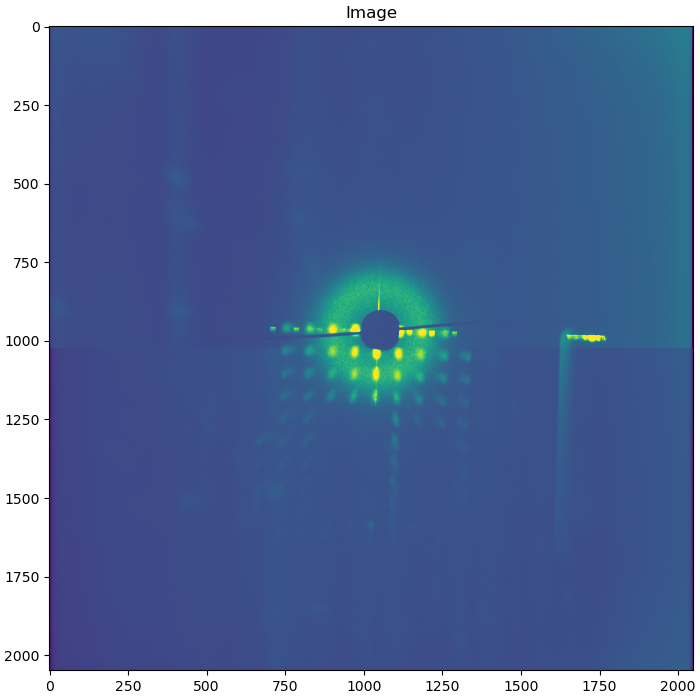

In [10]:
# Load image
if isinstance(im_id,list):
    images = np.stack([load_processing(idx,img_indices = img_indices_im, camera_type = camera_type)[0] for idx in im_id])
    image = np.mean(images,axis=0)
    print("list")
else:
    image, images = load_processing(im_id, img_indices = img_indices_im)
    
# Plot
fig, ax = cimshow(helper.log_clip(image))
#fig, ax = cimshow(image)
ax.set_title("Image")

## Load dark image

interactive(children=(FloatRangeSlider(value=(602.2156862745098, 652.2745098039215), description='contrast', l…

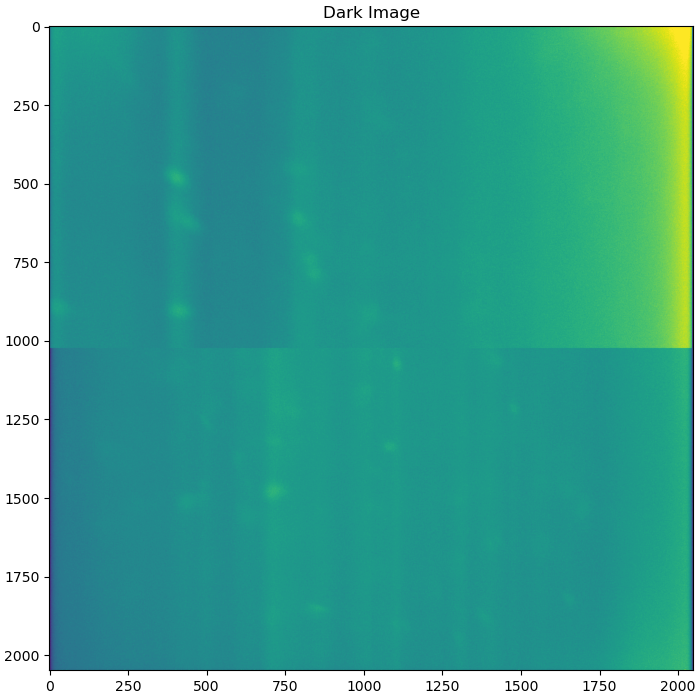

In [11]:
# Load image
if dark_id_im is not None:
    dark, darks = load_processing(dark_id_im, img_indices = None, crop=None)
    image -= dark
    images -= dark

    # Plot
    fig, ax = cimshow(dark)
    ax.set_title("Dark Image")

interactive(children=(FloatRangeSlider(value=(-30.215686274509835, 293.72549019607845), description='contrast'…

interactive(children=(IntSlider(value=0, description='nr', max=116), Output()), _dom_classes=('widget-interact…

(<Figure size 700x700 with 1 Axes>, <Axes: >)

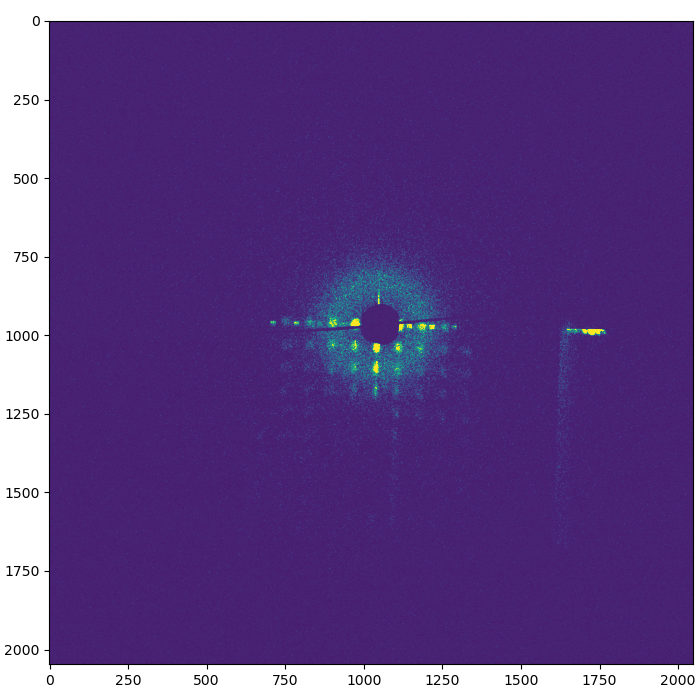

In [12]:
cimshow(images)

# Find photons

In [13]:
from scipy.ndimage import generate_binary_structure, label
from scipy.ndimage import sum as label_sum
from scipy.ndimage import maximum as label_maximum
from scipy import signal


def image_to_photon_statistics(image, kernel, threshold_area, threshold_intensity):
    # Calc convolution with kernel
    im_convolve = signal.convolve2d(image, kernel, boundary="symm", mode="same")

    # Generate structuring element to find connectivity
    structure = generate_binary_structure(2, 2)

    # Get mask
    photon_mask = im_convolve > threshold_intensity

    # Indentify features
    labeled_array, num_features = label(photon_mask, structure=structure)
    filtered_label = np.arange(1, num_features + 1).astype(int)  # starts at 1
    filtered_idx = filtered_label > 0  # Boolean True array

    # Calc area per feature for filtering
    l_area = label_sum(photon_mask, labeled_array, filtered_label)

    # Filtering conditions
    filtered_idx = l_area <= threshold_area

    # Only filtered features of label list
    filtered_label = filtered_label[filtered_idx]

    # Further parameter calculations
    # Take maximum of labels as total adu count per photon
    photon_adu = label_maximum(im_convolve, labeled_array, filtered_label)

    return im_convolve, photon_mask, photon_adu

Text(0, 0.5, 'Frequency')

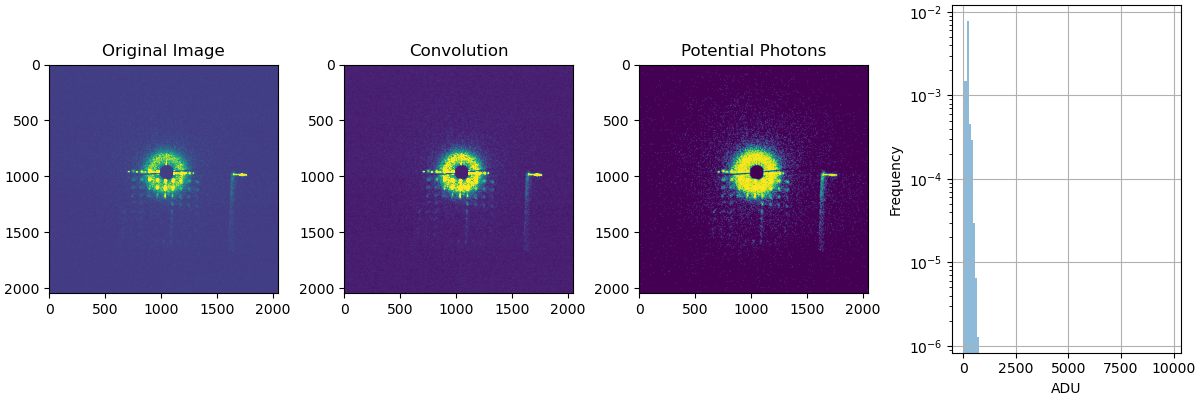

In [19]:
# Kernel parameter
kernel_size = 3  # 4
kernel = np.ones((kernel_size, kernel_size))

# Find potential photons
test = images[0]

# Get information about statistics
im_convolve, photon_mask, photon_adu = image_to_photon_statistics(
    test, kernel, 16, 150 # 25,3000
)

# Calc histogram
# Histogram of state changes
bins = np.arange(0, 10e3, 100)
hist_photon, _ = np.histogram(photon_adu, bins=bins, density=True)

# Plotting
fig, ax = plt.subplots(1, 4, figsize=(12, 4))
mi, ma = np.percentile(test, [1, 99])
ax[0].imshow(test, vmin=mi, vmax=ma)
ax[0].set_title("Original Image")

mi, ma = np.percentile(im_convolve, [1, 99])
ax[1].imshow(im_convolve, vmin=mi, vmax=ma)
ax[1].set_title("Convolution")
ax[1].sharex(ax[0])
ax[1].sharey(ax[0])

ax[2].imshow(photon_mask)
ax[2].set_title("Potential Photons")
ax[2].sharex(ax[0])
ax[2].sharey(ax[0])

ax[3].bar(bins[:-1], hist_photon, width=100, label="Only potential photons", alpha=0.5)
# ax[3].legend()
ax[3].grid()
ax[3].set_yscale("log")
ax[3].set_xlabel("ADU")
ax[3].set_ylabel("Frequency")

In [20]:
def image_to_photon_statistics_batch(image):
    # Kernel parameter
    kernel_size = 4
    kernel = np.ones((kernel_size, kernel_size))

    _, _, photon_adu = image_to_photon_statistics(image, kernel, 16, 150)

    return photon_adu

In [23]:
from multiprocessing import Pool

# Find potential photons in large image stack
# Get information about statistics
with Pool(processes=64) as pool:
    photon_adus = pool.map(image_to_photon_statistics_batch, images)

# Stack to single array
photon_adus = np.hstack(photon_adus)

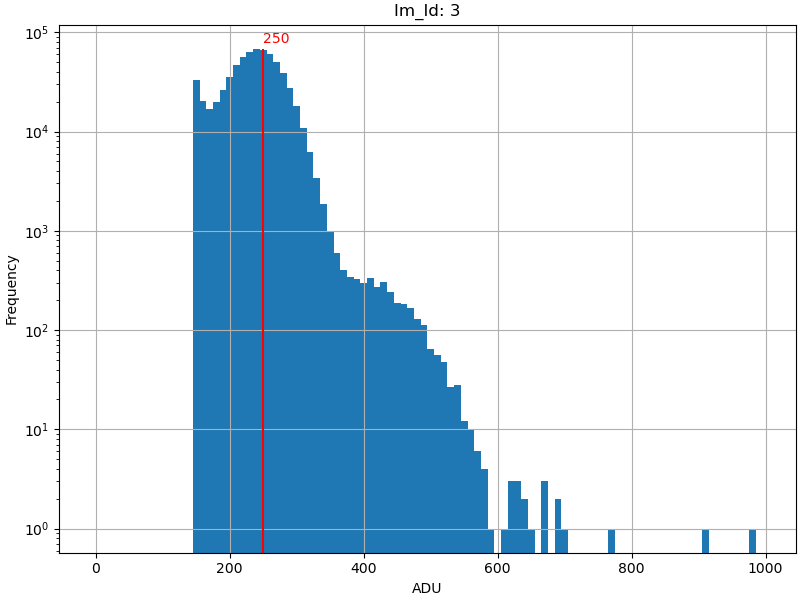

In [28]:

# Calc histogram and find peaks
from scipy.signal import find_peaks

# Histogram
bin_width = 10
bins = np.arange(0, 1e3 + 1, bin_width)
hist_photon, _ = np.histogram(photon_adus, bins=bins, density=False)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(
    bins[:-1],
    hist_photon,
    width=bin_width,
    label="Only potential photons",
)
# ax.legend()
ax.grid()
ax.set_yscale("log")
ax.set_xlabel("ADU")
ax.set_ylabel("Frequency")
ax.set_title("Im_Id: %s" % im_id)

# Detect peaks
peaks, _ = find_peaks(
    gaussian_filter(np.log10(hist_photon + 0.01), 5), height=1.5, distance=200
)  # height=0 to include all peaks

for peak in peaks:
    ax.vlines(bins[peak], ymin=0, ymax=np.max(hist_photon + 0.01), color="r", label="a")
    ax.text(
        bins[peak],
        np.max(hist_photon + 0.01) + 10000,
        f"%d" % bins[peak],
        color="r",
    )